# ------------------------ Evaluate Tune and Select Final Model ------------------------

### Importing important packages

In [2]:
# ============================================================
# BLOCK 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import math as math
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

from sklearn.model_selection import cross_validate, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

from scipy import stats

In [3]:
# ============================================================
# BLOCK 2 — LOAD ML PREPARED DATA
# ============================================================
#
# Load the revised ML dataset created in Notebook 03.
# estimated_delivery_minutes has already been removed from
# the feature set.
# ============================================================

ml_prepared_data = pd.read_pickle(
    "EuroEats_ML_prepared_data.pkl"
)

X_train = ml_prepared_data["X_train"]
X_test = ml_prepared_data["X_test"]

y_train = ml_prepared_data["y_train"]
y_test = ml_prepared_data["y_test"]

numeric_features = ml_prepared_data["numeric_features"]
categorical_features = ml_prepared_data["categorical_features"]

print("ML data loaded successfully.")
print("-" * 60)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape : {y_test.shape}")

print("\nTarget variable: actual_delivery_minutes")

print(
    "\nestimated_delivery_minutes present:",
    "estimated_delivery_minutes" in X_train.columns
)

ML data loaded successfully.
------------------------------------------------------------
X_train shape: (800, 26)
X_test shape : (200, 26)
y_train shape: (800,)
y_test shape : (200,)

Target variable: actual_delivery_minutes

estimated_delivery_minutes present: False


In [4]:
# ============================================================
# BLOCK 3 — DEFINE CANDIDATE MODELS
# ============================================================
#
# Based on the baseline results from Notebook 04:
#
# 1. Gradient Boosting had the best Test MAE and Test R².
# 2. Linear Regression had the smallest train-test performance gap.
#
# These two models will therefore be evaluated further.
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


# ------------------------------------------------------------
# Preprocessing for Linear Regression
# ------------------------------------------------------------

numeric_transformer_linear = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

preprocessor_linear = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_linear, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


# ------------------------------------------------------------
# Preprocessing for Gradient Boosting
# ------------------------------------------------------------

numeric_transformer_tree = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_tree, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


# ------------------------------------------------------------
# Candidate models
# ------------------------------------------------------------

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_linear),
        ("model", LinearRegression())
    ]
)

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_tree),
        ("model", GradientBoostingRegressor(
            random_state=42
        ))
    ]
)

print("Candidate models defined successfully.")

Candidate models defined successfully.


In [5]:
# ============================================================
# BLOCK 4 — CROSS-VALIDATION OF CANDIDATE MODELS
# ============================================================
#
# Cross-validation is performed only on the training data.
# The test set remains untouched for final evaluation.
# ============================================================

candidate_models = {
    "Linear Regression": linear_model,
    "Gradient Boosting": gradient_boosting_model
}

cv_results = []

for model_name, model in candidate_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=5,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R²": scores["test_R2"].mean()
    })


cv_results_df = pd.DataFrame(cv_results)

print("Cross-validation results:")
print(
    cv_results_df.round(3)
)

Cross-validation results:
               Model  CV MAE  CV RMSE  CV R²
0  Linear Regression   7.970   10.434  0.700
1  Gradient Boosting   7.208    9.854  0.733


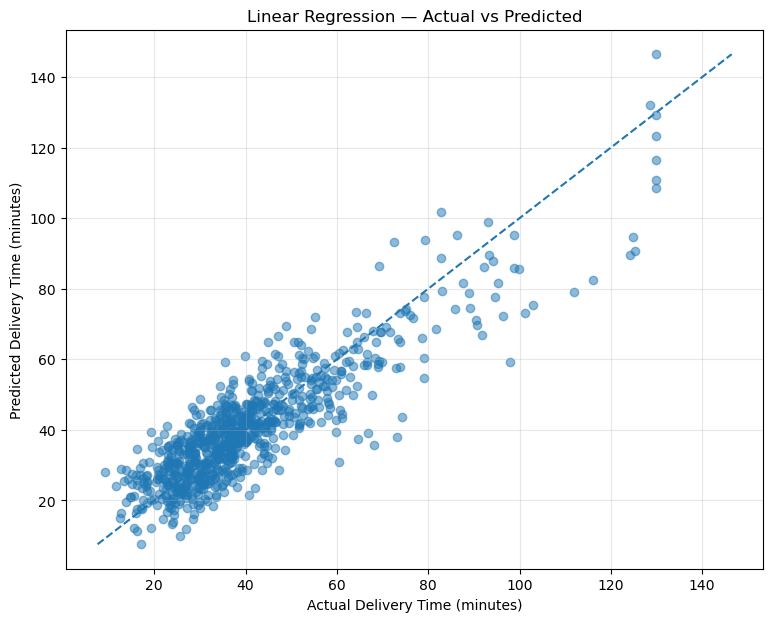

In [6]:
# ============================================================
# BLOCK 5 — LINEAR REGRESSION ASSUMPTION CHECK
# ACTUAL VS PREDICTED
# ============================================================

linear_model.fit(X_train, y_train)

linear_train_pred = linear_model.predict(X_train)

plt.figure(figsize=(9, 7))

plt.scatter(
    y_train,
    linear_train_pred,
    alpha=0.5
)

min_value = min(
    y_train.min(),
    linear_train_pred.min()
)

max_value = max(
    y_train.max(),
    linear_train_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title("Linear Regression — Actual vs Predicted")
plt.grid(alpha=0.3)

plt.show()

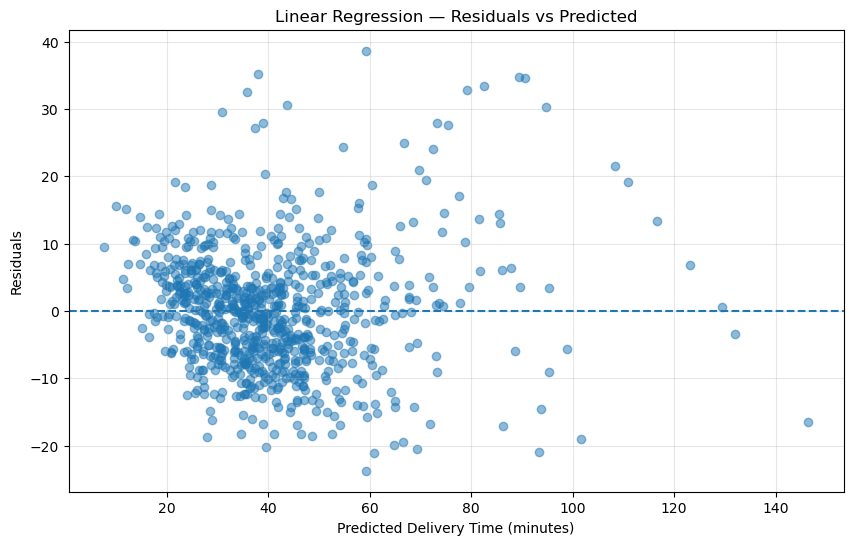

In [7]:
# ============================================================
# BLOCK 6 — LINEAR REGRESSION RESIDUAL ANALYSIS
# RESIDUALS VS PREDICTED
# ============================================================

linear_residuals = y_train - linear_train_pred

plt.figure(figsize=(10, 6))

plt.scatter(
    linear_train_pred,
    linear_residuals,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Delivery Time (minutes)")
plt.ylabel("Residuals")
plt.title("Linear Regression — Residuals vs Predicted")
plt.grid(alpha=0.3)

plt.show()

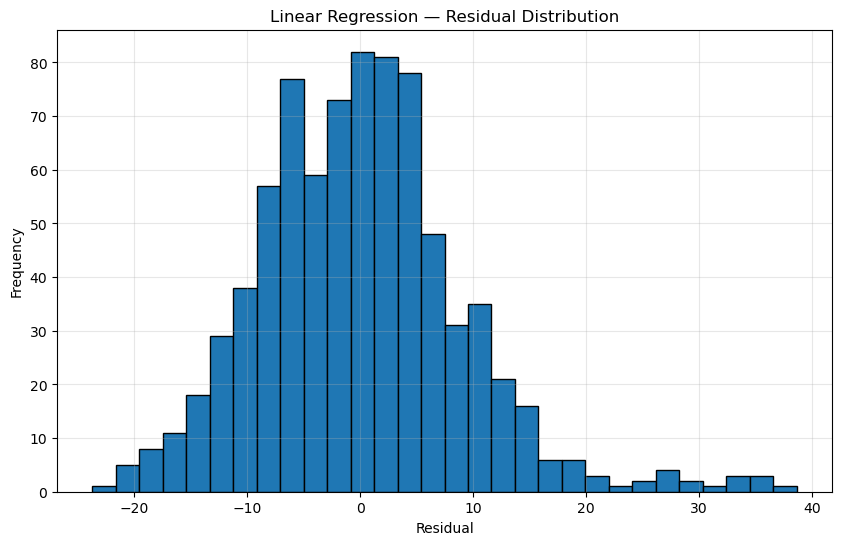

In [8]:
# ============================================================
# BLOCK 7 — LINEAR REGRESSION RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    linear_residuals,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Linear Regression — Residual Distribution")
plt.grid(alpha=0.3)

plt.show()

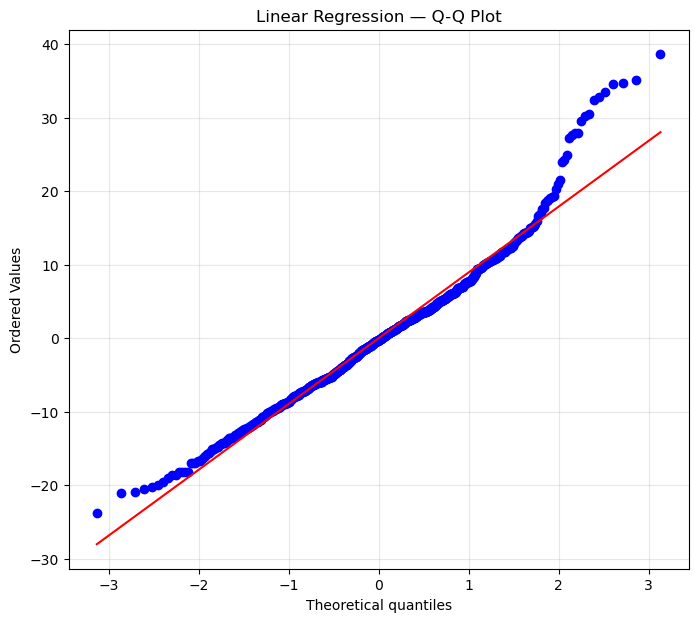

In [9]:
# ============================================================
# BLOCK 8 — LINEAR REGRESSION Q-Q PLOT
# ============================================================

plt.figure(figsize=(8, 7))

stats.probplot(
    linear_residuals,
    dist="norm",
    plot=plt
)

plt.title("Linear Regression — Q-Q Plot")
plt.grid(alpha=0.3)

plt.show()

In [10]:
# ============================================================
# BLOCK 9 — GRADIENT BOOSTING HYPERPARAMETER TUNING
# ============================================================
#
# A small parameter grid is used to improve Gradient Boosting
# without making the training process unnecessarily expensive.
# ============================================================

gb_params = {
    "model__n_estimators": [100, 150],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

gb_grid = GridSearchCV(
    estimator=gradient_boosting_model,
    param_grid=gb_params,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(
    X_train,
    y_train
)

print("\nBest Gradient Boosting parameters:")
print(gb_grid.best_params_)

print(
    f"\nBest CV MAE: {-gb_grid.best_score_:.3f} minutes"
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Gradient Boosting parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 150}

Best CV MAE: 7.064 minutes


In [11]:
# ============================================================
# BLOCK 9 — GRADIENT BOOSTING HYPERPARAMETER TUNING
# ============================================================
#
# A small parameter grid is used to improve Gradient Boosting
# without making the training process unnecessarily expensive.
# ============================================================

gb_params = {
    "model__n_estimators": [100, 150],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [2, 3]
}

gb_grid = GridSearchCV(
    estimator=gradient_boosting_model,
    param_grid=gb_params,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(
    X_train,
    y_train
)

print("\nBest Gradient Boosting parameters:")
print(gb_grid.best_params_)

print(
    f"\nBest CV MAE: {-gb_grid.best_score_:.3f} minutes"
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Gradient Boosting parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 150}

Best CV MAE: 7.064 minutes


In [13]:
# ============================================================
# BLOCK 10 — EXTRACT TUNED GRADIENT BOOSTING MODEL
# ============================================================

tuned_gb_model = gb_grid.best_estimator_

print("Tuned Gradient Boosting model created successfully.")

Tuned Gradient Boosting model created successfully.


In [14]:
# ============================================================
# BLOCK 11 — COMPARE FINAL CANDIDATE MODELS
# ============================================================
#
# The test set is used here for model comparison.
# ============================================================

linear_test_pred = linear_model.predict(X_test)

gb_test_pred = tuned_gb_model.predict(X_test)


comparison_results = []

for model_name, predictions in [
    ("Linear Regression", linear_test_pred),
    ("Tuned Gradient Boosting", gb_test_pred)
]:

    comparison_results.append({
        "Model": model_name,
        "Test MAE": mean_absolute_error(
            y_test,
            predictions
        ),
        "Test RMSE": np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        ),
        "Test R²": r2_score(
            y_test,
            predictions
        )
    })


comparison_df = pd.DataFrame(comparison_results)

print("Final candidate model comparison:")
print(
    comparison_df.round(3)
)

Final candidate model comparison:
                     Model  Test MAE  Test RMSE  Test R²
0        Linear Regression     7.065      9.543    0.795
1  Tuned Gradient Boosting     6.852      9.315    0.804


In [15]:
# ============================================================
# BLOCK 12 — SELECT FINAL MODEL
# ============================================================
#
# Test MAE is used as the primary metric because the business
# problem is predicting delivery time in minutes.
#
# Lower MAE means smaller average prediction error.
# ============================================================

best_model_name = (
    comparison_df
    .sort_values("Test MAE")
    .iloc[0]["Model"]
)

if best_model_name == "Linear Regression":

    final_model = linear_model

else:

    final_model = tuned_gb_model


print("Final model selected:")
print(best_model_name)

Final model selected:
Tuned Gradient Boosting


In [16]:
# ============================================================
# BLOCK 13 — FINAL MODEL EVALUATION
# ============================================================

final_train_pred = final_model.predict(X_train)
final_test_pred = final_model.predict(X_test)


final_train_mae = mean_absolute_error(
    y_train,
    final_train_pred
)

final_test_mae = mean_absolute_error(
    y_test,
    final_test_pred
)

final_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        final_train_pred
    )
)

final_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_test_pred
    )
)

final_train_r2 = r2_score(
    y_train,
    final_train_pred
)

final_test_r2 = r2_score(
    y_test,
    final_test_pred
)


print("FINAL MODEL PERFORMANCE")
print("=" * 50)

print(f"Model       : {best_model_name}")

print(f"\nTrain MAE   : {final_train_mae:.3f} minutes")
print(f"Test MAE    : {final_test_mae:.3f} minutes")

print(f"\nTrain RMSE  : {final_train_rmse:.3f} minutes")
print(f"Test RMSE   : {final_test_rmse:.3f} minutes")

print(f"\nTrain R²    : {final_train_r2:.3f}")
print(f"Test R²     : {final_test_r2:.3f}")

FINAL MODEL PERFORMANCE
Model       : Tuned Gradient Boosting

Train MAE   : 5.759 minutes
Test MAE    : 6.852 minutes

Train RMSE  : 7.609 minutes
Test RMSE   : 9.315 minutes

Train R²    : 0.846
Test R²     : 0.804


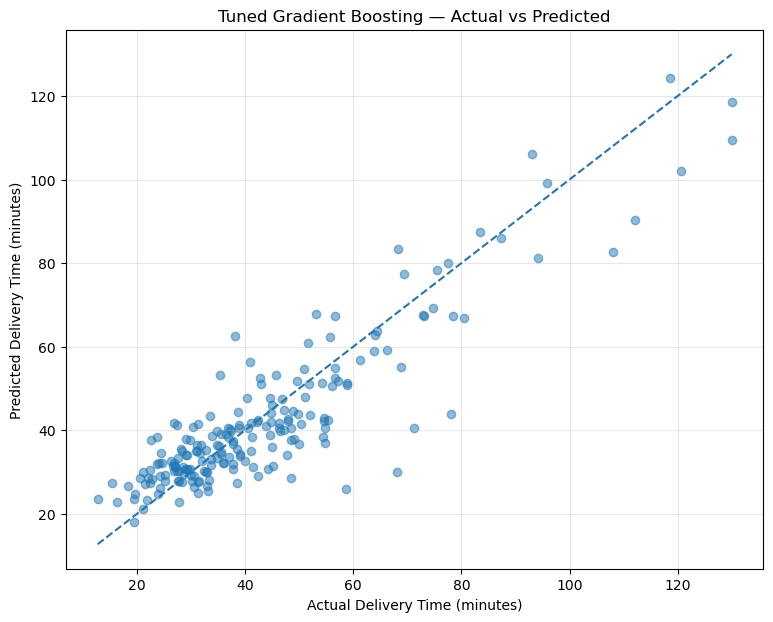

In [17]:
# ============================================================
# BLOCK 14 — FINAL MODEL: ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(9, 7))

plt.scatter(
    y_test,
    final_test_pred,
    alpha=0.5
)

min_value = min(
    y_test.min(),
    final_test_pred.min()
)

max_value = max(
    y_test.max(),
    final_test_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Delivery Time (minutes)")
plt.ylabel("Predicted Delivery Time (minutes)")
plt.title(f"{best_model_name} — Actual vs Predicted")
plt.grid(alpha=0.3)

plt.show()

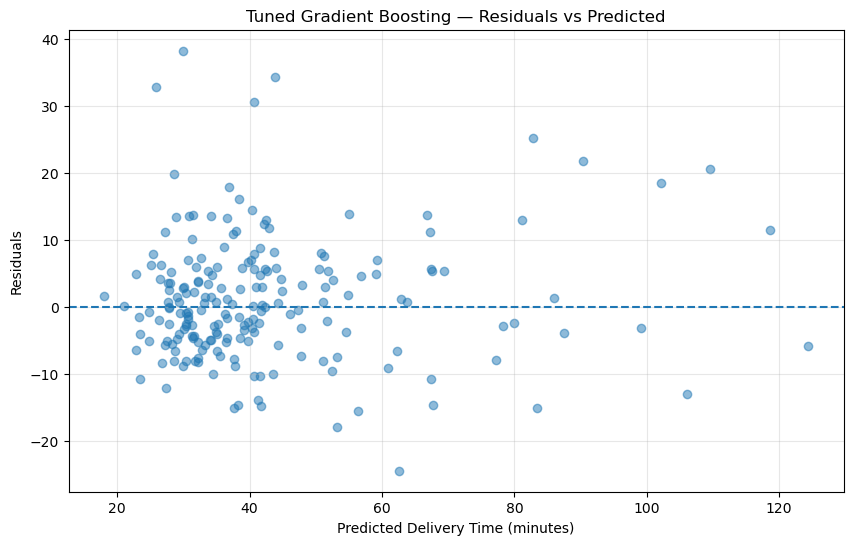

In [18]:
# ============================================================
# BLOCK 15 — FINAL MODEL RESIDUAL ANALYSIS
# ============================================================

final_residuals = y_test - final_test_pred

plt.figure(figsize=(10, 6))

plt.scatter(
    final_test_pred,
    final_residuals,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Delivery Time (minutes)")
plt.ylabel("Residuals")
plt.title(f"{best_model_name} — Residuals vs Predicted")
plt.grid(alpha=0.3)

plt.show()

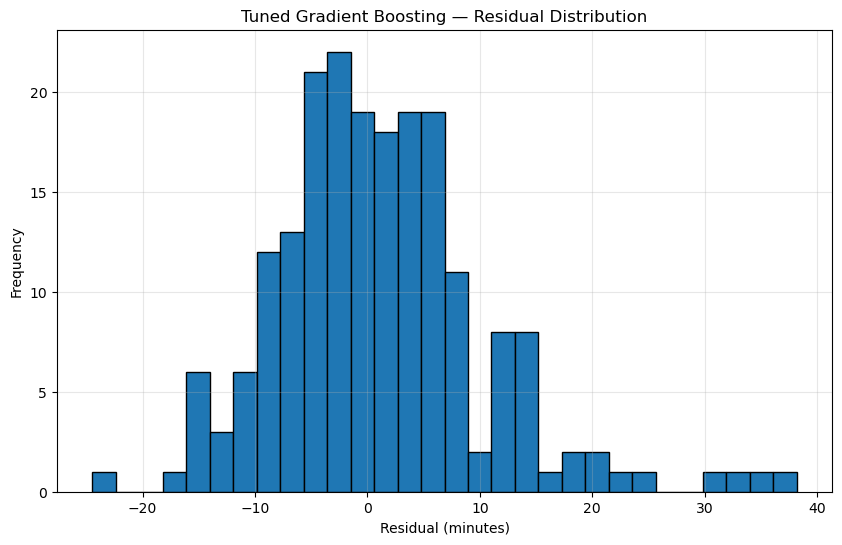

In [19]:
# ============================================================
# BLOCK 16 — FINAL MODEL RESIDUAL DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    final_residuals,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Residual (minutes)")
plt.ylabel("Frequency")
plt.title(f"{best_model_name} — Residual Distribution")
plt.grid(alpha=0.3)

plt.show()

Top 20 features:
                           Feature  Importance
4                 num__distance_km      0.6697
15         cat__traffic_level_High      0.1408
14          num__average_speed_kmh      0.1022
8    num__average_preparation_time      0.0388
16          cat__traffic_level_Low      0.0133
9        num__average_daily_orders      0.0054
5               num__temperature_c      0.0051
11           num__years_experience      0.0045
12              num__driver_rating      0.0045
1                num__subtotal_eur      0.0024
0             num__number_of_items      0.0023
13       num__completed_deliveries      0.0022
7           num__restaurant_rating      0.0019
20     cat__weather_condition_Rain      0.0012
62                cat__city_Prague      0.0010
2            num__delivery_fee_eur      0.0008
68          cat__city_Thessaloniki      0.0008
104      cat__vehicle_type_Bicycle      0.0007
6                 num__price_level      0.0005
63                  cat__city_Rome      0.0

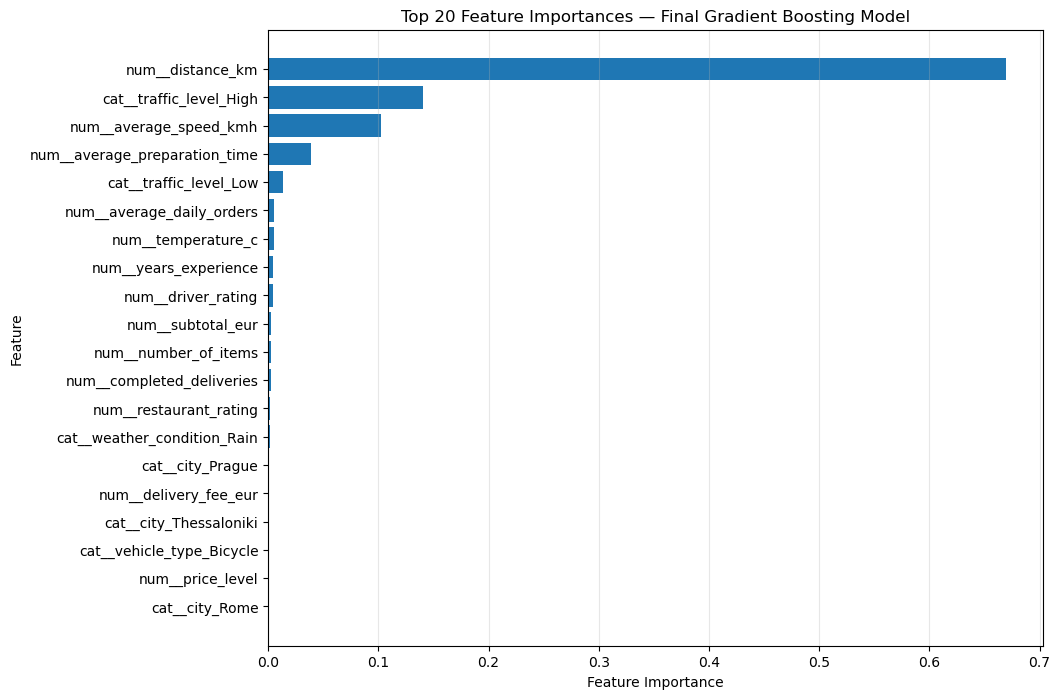

In [20]:
# ============================================================
# BLOCK 17 — FEATURE IMPORTANCE
# ============================================================

if best_model_name == "Tuned Gradient Boosting":

    preprocessor = final_model.named_steps["preprocessor"]
    model = final_model.named_steps["model"]

    feature_names = preprocessor.get_feature_names_out()

    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model.feature_importances_
    })

    feature_importance_df = (
        feature_importance_df
        .sort_values(
            "Importance",
            ascending=False
        )
        .head(20)
    )

    print("Top 20 features:")
    print(
        feature_importance_df.round(4)
    )

    plt.figure(figsize=(10, 8))

    plt.barh(
        feature_importance_df["Feature"][::-1],
        feature_importance_df["Importance"][::-1]
    )

    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.title("Top 20 Feature Importances — Final Gradient Boosting Model")
    plt.grid(axis="x", alpha=0.3)

    plt.show()

else:

    print(
        "Feature importance plot skipped because "
        "the final model is Linear Regression."
    )

In [21]:
# ============================================================
# BLOCK 18 — DECILE ANALYSIS
# ============================================================
#
# The test observations are ranked by predicted delivery time
# and divided into 10 approximately equal-sized groups.
#
# Each decile compares:
#   - Average predicted delivery time
#   - Average actual delivery time
#   - Average prediction error
#   - MAE
#
# This helps understand model performance across different
# predicted delivery-time ranges.
# ============================================================

decile_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": final_test_pred
})

decile_df = decile_df.sort_values(
    "Predicted"
).reset_index(drop=True)

decile_df["Decile"] = pd.qcut(
    decile_df.index,
    q=10,
    labels=False
) + 1


decile_analysis = (
    decile_df
    .groupby("Decile")
    .agg(
        Observations=("Actual", "count"),
        Avg_Actual=("Actual", "mean"),
        Avg_Predicted=("Predicted", "mean"),
        MAE=("Actual", lambda x:
            np.mean(
                np.abs(
                    x.values -
                    decile_df.loc[x.index, "Predicted"].values
                )
            )
        )
    )
    .reset_index()
)


decile_analysis["Error"] = (
    decile_analysis["Avg_Predicted"]
    - decile_analysis["Avg_Actual"]
)

decile_analysis["Error_%"] = (
    decile_analysis["Error"]
    / decile_analysis["Avg_Actual"]
) * 100


print("DECILE ANALYSIS")
print("=" * 70)

print(
    decile_analysis.round(3)
)

DECILE ANALYSIS
   Decile  Observations  Avg_Actual  Avg_Predicted     MAE  Error  Error_%
0       1            20      25.440         24.806   6.848 -0.634   -2.494
1       2            20      30.950         28.575   6.545 -2.375   -7.673
2       3            20      31.575         30.763   4.623 -0.812   -2.572
3       4            20      32.985         33.016   5.145  0.031    0.094
4       5            20      36.440         35.847   5.611 -0.593   -1.626
5       6            20      38.700         39.060   6.755  0.360    0.930
6       7            20      43.695         41.522   7.814 -2.173   -4.974
7       8            20      49.885         46.938   6.554 -2.947   -5.908
8       9            20      56.420         57.860   8.232  1.440    2.552
9      10            20      89.705         87.305  10.394 -2.400   -2.675


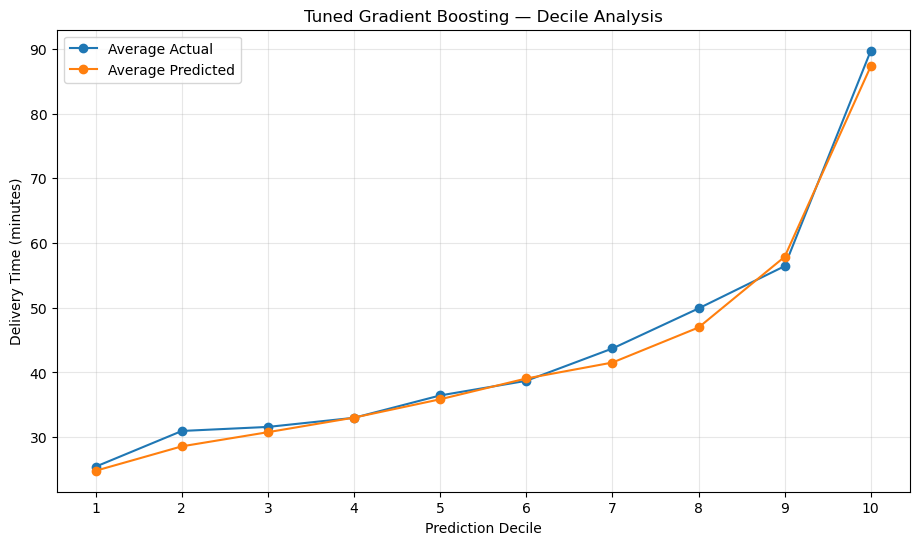

In [22]:
# ============================================================
# BLOCK 19 — DECILE ANALYSIS VISUALIZATION
# ============================================================

plt.figure(figsize=(11, 6))

plt.plot(
    decile_analysis["Decile"],
    decile_analysis["Avg_Actual"],
    marker="o",
    label="Average Actual"
)

plt.plot(
    decile_analysis["Decile"],
    decile_analysis["Avg_Predicted"],
    marker="o",
    label="Average Predicted"
)

plt.xlabel("Prediction Decile")
plt.ylabel("Delivery Time (minutes)")
plt.title(f"{best_model_name} — Decile Analysis")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [23]:
# ============================================================
# BLOCK 20 — SAVE FINAL MODEL
# ============================================================
#
# Save the complete preprocessing + model pipeline.
# This allows the same preprocessing steps to be applied when
# making predictions on new data.
# ============================================================

pd.to_pickle(
    final_model,
    "EuroEats_Final_Regression_Model.pkl"
)

print("Final model saved successfully.")
print("File: EuroEats_Final_Regression_Model.pkl")
print(f"Model: {best_model_name}")

Final model saved successfully.
File: EuroEats_Final_Regression_Model.pkl
Model: Tuned Gradient Boosting


###### ------------------------------------------------------------------------------------------------------------ THE END ------------------------------------------------------------------------------------------------------------